# Chapter 3: Estimating Expected Returns and Covariances

## 3.1 Estimating Expected Returns

## Listing 3.1

In [1]:
import pandas as pd
import yfinance as yf

df = yf.download("AAPL", start='2000-01-03', end='2023-12-30', auto_adjust=False)
df.tail()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2023-12-22,191.974670,193.600006,195.410004,192.970001,195.179993,37149600
2023-12-26,191.429291,193.050003,193.889999,192.830002,193.610001,28919300
2023-12-27,191.528442,193.149994,193.500000,191.089996,192.490005,48087700
2023-12-28,191.954849,193.580002,194.660004,193.169998,194.139999,34049900
2023-12-29,190.913666,192.529999,194.399994,191.729996,193.899994,42672100


In [2]:
stocks = ['AAPL', 'FE', 'WMT']
stock_prices = yf.download(stocks, start='2000-01-03', end='2023-12-30', auto_adjust=False)['Adj Close']
stock_prices.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,FE,WMT
Date,,,
2000-01-03,0.840094,6.988982,14.239622
2000-01-04,0.769266,6.988982,13.706801
2000-01-05,0.780523,7.246363,13.427073
2000-01-06,0.712977,7.266162,13.573596
2000-01-07,0.746750,7.305762,14.599273


In [3]:
stock_returns = stock_prices.pct_change()
stock_returns.head()

Ticker,AAPL,FE,WMT
Date,,,
2000-01-03,NaN,NaN,NaN
2000-01-04,-0.084310,0.000000,-0.037418
2000-01-05,0.014633,0.036827,-0.020408
2000-01-06,-0.086539,0.002732,0.010913
2000-01-07,0.047369,0.005450,0.075564


In [4]:
stock_returns.mean()*252

Ticker
AAPL    0.306962
FE      0.099765
WMT     0.081381
dtype: float64

## Listing 3.2

In [5]:
import pandas_datareader as pdr

rf = pdr.DataReader('TB3MS', 'fred', start='2000-01-01', end='2023-12-30')
rf.head()

,TB3MS
DATE,
2000-01-01,5.32
2000-02-01,5.55
2000-03-01,5.69
2000-04-01,5.66
2000-05-01,5.79


In [6]:
mkt_prices = yf.download('SPY', start='2000-01-03', end='2023-12-30', auto_adjust=False)['Adj Close']

[*********************100%***********************]  1 of 1 completed


## Listing 3.3

In [7]:
import statsmodels.api as sm

stock_prices_monthly = stock_prices.resample('MS').first()
mkt_prices_monthly = mkt_prices.resample('MS').first()
aapl_returns_monthly = stock_prices_monthly['AAPL'].pct_change()
mkt_returns_monthly = mkt_prices_monthly.pct_change()
y = (aapl_returns_monthly - rf['TB3MS']/100/12).dropna()
X = (mkt_returns_monthly['SPY'] - rf['TB3MS']/100/12).dropna()
model = sm.OLS(y,X)
results = model.fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.306
Model:                            OLS   Adj. R-squared (uncentered):              0.304
Method:                 Least Squares   F-statistic:                              126.1
Date:                Wed, 27 Aug 2025   Prob (F-statistic):                    1.75e-24
Time:                        02:37:30   Log-Likelihood:                          262.02
No. Observations:                 287   AIC:                                     -522.0
Df Residuals:                     286   BIC:                                     -518.4
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [8]:
print('The beta for AAPL is: ', results.params)

The beta for AAPL is:  x1    1.31732
dtype: float64


The beta for FE:

In [9]:
fe_returns_monthly = stock_prices_monthly['FE'].pct_change()
y = (fe_returns_monthly - rf['TB3MS']/100/12).dropna()
model = sm.OLS(y,X)
results = model.fit()
print('The beta for FE is: ', results.params)

The beta for FE is:  x1    0.298144
dtype: float64


The beta for WMT:

In [10]:
wmt_returns_monthly = stock_prices_monthly['WMT'].pct_change()
y = (wmt_returns_monthly - rf['TB3MS']/100/12).dropna()
model = sm.OLS(y,X)
results = model.fit()
print('The beta for WMT is: ', results.params)

The beta for WMT is:  x1    0.477789
dtype: float64


In [11]:
print('The current risk-free rate is', rf['TB3MS'].iloc[-1],'%')

The current risk-free rate is 5.24 %


In [12]:
print('The avg annualized market return is', mkt_returns_monthly['SPY'].mean()*12*100, '%')

The avg annualized market return is 8.074061458412686 %


## Listing 3.4

raw bond average returns  0.09673030238651528
excess bond average returns  0.06364354439564769


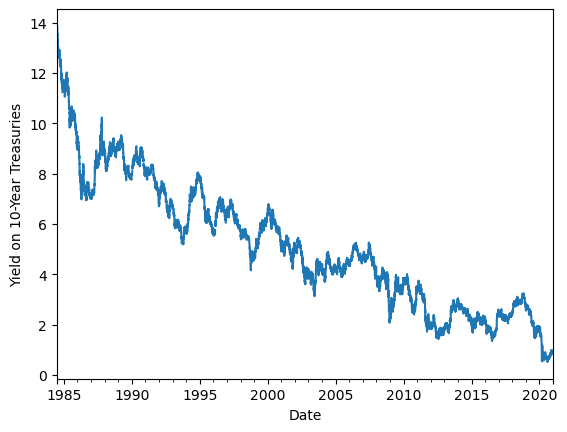

In [13]:
start = '1984-06-29'
end = '2020-12-31'
symbol = 'BAMLCC8A015PYTRIV'

bond = pdr.DataReader(symbol, 'fred', start=start, end=end) #A
bond_monthly = bond.resample('ME').last()
bond_returns_monthly = bond_monthly.pct_change()

TenYr = pdr.DataReader('DGS10', 'fred', start='1984-06-29', end='2020-12-31') #B
TenYr_monthly = TenYr.resample('ME').last()
TenYr_change_monthly = TenYr_monthly.diff().dropna()/100.
TenYr_change_monthly.rename(columns={'DGS10': 'Change 10Yr Yield'}, inplace=True)

rf = pdr.DataReader('DTB3', 'fred', start='1984-06-29', end='2020-12-31') #C
rf_monthly = rf.resample('ME').last()/100

TenYr.plot(xlabel='Date', ylabel='Yield on 10-Year Treasuries', legend=False) #D

print('raw bond average returns ', bond_returns_monthly[symbol].mean()*12)
print('excess bond average returns ', (bond_returns_monthly[symbol] -
                                       rf_monthly['DTB3'].shift()/12).mean()*12)

#A Download corporate bond data
#B Download Treasury yield data
#C Download short-term risk-free rate data
#D The plot of Treasury yields displayed in Figure 3.2

## Listing 3.5

In [14]:
y = (bond_returns_monthly[symbol] - rf_monthly['DTB3'].shift()/12).dropna()
X = TenYr_change_monthly
X = sm.add_constant(X)
common_dates = X.index.intersection(y.index)
X = X.loc[common_dates]
model = sm.OLS(y,X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     364.4
Date:                Wed, 27 Aug 2025   Prob (F-statistic):           1.72e-59
Time:                        02:38:12   Log-Likelihood:                 1123.3
No. Observations:                 438   AIC:                            -2243.
Df Residuals:                     436   BIC:                            -2234.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0036      0.00

In [15]:
print('The expected return after stripping out valuation is ',results.params.iloc[0]*12)

The expected return after stripping out valuation is  0.04261614539214145


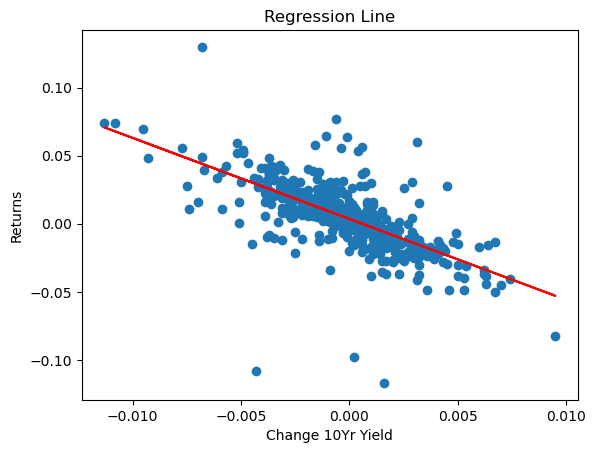

In [16]:
# Plot the regression line
import matplotlib.pyplot as plt

plt.plot(X['Change 10Yr Yield'], results.fittedvalues, color='red')
plt.scatter(X['Change 10Yr Yield'], y)
plt.xlabel('Change 10Yr Yield')
plt.ylabel('Returns')
plt.title('Regression Line')
plt.show()

## Listing 3.6

In [17]:
start = '1983-01-01'
end = '2023-01-01'

stock = yf.download('VFINX', start=start, end=end, auto_adjust=False)
stock_annual = stock.resample('YS').first()
stock_returns_annual = stock_annual['Adj Close'].pct_change()

CAPE = pd.read_excel('ie_data.xls', sheet_name='Data',
usecols=['Date', 'CAPE'], skiprows=7) #A
CAPE = CAPE.dropna()
CAPE['Year'] = CAPE['Date'].astype(int) #B
CAPE['Month'] = round(100*(CAPE['Date']-CAPE['Year'])).astype(int) #C
CAPE['Year'] = CAPE['Year'].astype(str)
CAPE['Month'] = CAPE['Month'].astype(str)
CAPE['Date'] = CAPE['Year']+'-'+CAPE['Month']+'-'+'01'
CAPE = CAPE.set_index('Date')
CAPE.index = pd.to_datetime(CAPE.index, format='%Y-%m-%d')
CAPE.drop(columns=['Year', 'Month'], inplace=True)
CAPE = CAPE.resample('YS').first()
CAPE['CAPE_returns'] = CAPE['CAPE'].pct_change()

rf = pdr.DataReader('DTB3', 'fred', start=start, end=end)
rf_annual = rf.resample('YS').first()/100

print('raw stock average returns ',stock_returns_annual['VFINX'].mean())
print('excess stock average returns ', (stock_returns_annual['VFINX'] -
                             rf_annual['DTB3'].shift()).mean())

#A Read Excel file with CAPE data
#B The year is the integer part of the date
#C The month is the decimal part of the date

[*********************100%***********************]  1 of 1 completed


raw stock average returns  0.12596749836701057
excess stock average returns  0.0909828829823952


## Listing 3.7

In [18]:
y = (stock_returns_annual['VFINX'] - rf_annual['DTB3'].shift()).dropna()
X = CAPE['CAPE_returns']
X = sm.add_constant(X)
common_dates = X.index.intersection(y.index)
X = X.loc[common_dates]
model = sm.OLS(y,X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.718
Method:                 Least Squares   F-statistic:                     97.61
Date:                Wed, 27 Aug 2025   Prob (F-statistic):           6.37e-12
Time:                        02:38:36   Log-Likelihood:                 41.915
No. Observations:                  39   AIC:                            -79.83
Df Residuals:                      37   BIC:                            -76.50
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0472      0.014      3.304   

## 3.2 Estimating Variances and Covariances

In [19]:
stock_returns.std() * (252**0.5)

Ticker
AAPL    0.392659
FE      0.258756
WMT     0.235451
dtype: float64

In [20]:
stock_returns.corr()

Ticker,AAPL,FE,WMT
Ticker,,,
AAPL,1.000000,0.209247,0.261399
FE,0.209247,1.000000,0.265760
WMT,0.261399,0.265760,1.000000


In [21]:
stock_returns.cov() * 252

Ticker,AAPL,FE,WMT
Ticker,,,
AAPL,0.154181,0.021260,0.024167
FE,0.021260,0.066955,0.016191
WMT,0.024167,0.016191,0.055437


In [22]:
import pandas as pd
import numpy as np

# Download S&P500 prices around the 1987 stock market crash
SP500 = yf.download('^GSPC', start='1987-10-07', end='1987-10-31', progress=False)['Close']

# Add a column for Percent Change
SP500['% Change'] = SP500['^GSPC'].pct_change()*100
SP500 = SP500.dropna()
SP500

C:\Users\reide\AppData\Local\Temp\ipykernel_16656\2161885965.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  SP500 = yf.download('^GSPC', start='1987-10-07', end='1987-10-31', progress=False)['Close']


Ticker,^GSPC,% Change
Date,,
1987-10-08,314.160004,-1.375025
1987-10-09,311.070007,-0.983574
1987-10-12,309.390015,-0.540069
1987-10-13,314.519989,1.658093
1987-10-14,305.230011,-2.953700
1987-10-15,298.079987,-2.342504
1987-10-16,282.700012,-5.159680
1987-10-19,224.839996,-20.466931
1987-10-20,236.830002,5.332684


## Listing 3.8

In [23]:
SP500 = yf.download('^GSPC', start='1987-01-01', end='2022-05-10')
SP500['Ret'] = SP500['Close'].pct_change()
SP500['Sq Ret'] = SP500['Ret']**2
AutoCorr = SP500['Sq Ret'].autocorr()
se = 1/(len(SP500)**0.5)
t_stat = AutoCorr/se

print('The autocorrelation of squared returns is', AutoCorr)
print('The standard error is', se)
print('The t-stat is', t_stat)

C:\Users\reide\AppData\Local\Temp\ipykernel_16656\145409995.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  SP500 = yf.download('^GSPC', start='1987-01-01', end='2022-05-10')
[*********************100%***********************]  1 of 1 completed

The autocorrelation of squared returns is 0.22277573731844041
The standard error is 0.010594028769395471
The t-stat is 21.028424801148873


C:\Users\reide\AppData\Local\Temp\ipykernel_16656\2302282376.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  VIX = yf.download('^VIX', start='2008-07-01', end='2009-10-16')['Close']
[*********************100%***********************]  1 of 1 completed


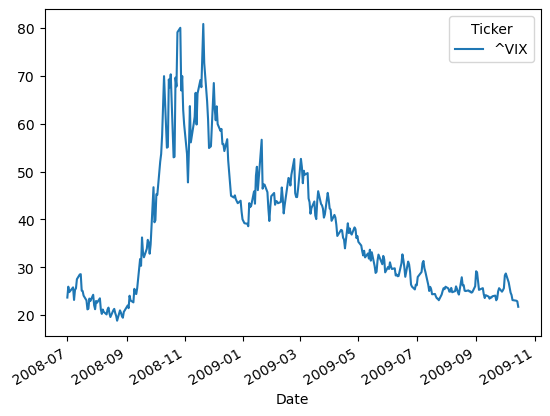

In [24]:
VIX = yf.download('^VIX', start='2008-07-01', end='2009-10-16')['Close']
VIX.plot();

## Listing 3.9

In [25]:
from arch import arch_model

AAPL_prices = yf.download('AAPL', start='2000-01-03', end='2022-05-24', auto_adjust=False)['Adj Close']
returns = 100 * AAPL_prices.pct_change().dropna()

horizon = 63
am = arch_model(returns)
res = am.fit()
forecasts = res.forecast(horizon=horizon)
print(forecasts.residual_variance.iloc[-1,:])

[*********************100%***********************]  1 of 1 completed

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1827372.236683488
Iteration:      2,   Func. Count:     14,   Neg. LLF: 2962269.0252194456
Iteration:      3,   Func. Count:     22,   Neg. LLF: 12379.132823529519
Iteration:      4,   Func. Count:     28,   Neg. LLF: 12359.906436217938
Iteration:      5,   Func. Count:     34,   Neg. LLF: 12486.383435151187
Iteration:      6,   Func. Count:     40,   Neg. LLF: 12285.696960851163
Iteration:      7,   Func. Count:     46,   Neg. LLF: 12297.379432844107
Iteration:      8,   Func. Count:     52,   Neg. LLF: 12785.445336582763
Iteration:      9,   Func. Count:     59,   Neg. LLF: 12279.133301873288
Iteration:     10,   Func. Count:     65,   Neg. LLF: 12278.745743741656
Iteration:     11,   Func. Count:     70,   Neg. LLF: 12278.74483622031
Iteration:     12,   Func. Count:     74,   Neg. LLF: 12278.744836220303
Optimization terminated successfully    (Exit mode 0)
            Current function value: 12278.74483622031
            Iterat

In [26]:
vol_forecast = (forecasts.residual_variance.iloc[-1,:].sum()*252/horizon)**0.5 / 100
print('Volatility forecast is ', vol_forecast)

Volatility forecast is  0.489728138004429


In [27]:
forecasts.residual_variance

,h.01,h.02,h.03,h.04,h.05,h.06,h.07,h.08,h.09,h.10,...,h.54,h.55,h.56,h.57,h.58,h.59,h.60,h.61,h.62,h.63
Date,,,,,,,,,,,,,,,,,,,,,
2022-05-23,9.871793,9.85811,9.844552,9.83112,9.817811,9.804625,9.791561,9.778617,9.765792,9.753086,...,9.296005,9.287628,9.279329,9.271106,9.26296,9.254888,9.24689,9.238967,9.231116,9.223338


In [28]:
Corr = [[ 1. ,  0.8, -0.2],
        [ 0.8,  1. ,  0.5],
        [-0.2,  0.5,  1. ]]
eigenvalues = np.linalg.eigvals(Corr)
print(np.all(eigenvalues > 0))

False


In [29]:
eigenvalues > 0

array([False,  True,  True])

In [30]:
Corr = [[ 1. ,  0.8, -0.2],
        [ 0.8,  1. ,  0.4],
        [-0.2,  0.4,  1. ]]
eigenvalues = np.linalg.eigvals(Corr)
print(np.all(eigenvalues > 0))

True
